In [1]:
!pip install transformers datasets torch scikit-learn pandas

In [2]:
import pandas as pd
import random
import numpy as np
import torch
import re
from sklearn.preprocessing import LabelEncoder
import torch
from torch.utils.data import Dataset
from transformers import BertModel
import torch.nn as nn
from tqdm.auto import tqdm
import os
import gc
from transformers import BertTokenizer
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from torch.optim import AdamW
from transformers import BartTokenizer
from transformers import BartModel, BartConfig
import torch.nn as nn
from transformers import BartConfig
from transformers.models.bart.modeling_bart import BartEncoder

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cuda


# Seed

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Data Preprocessing

In [4]:
train_df = pd.read_csv("trainmerged.csv")
val_df   = pd.read_csv("valmerged.csv")
test_df  = pd.read_csv("testmerged.csv")
print(train_df.head())

                                               Tweet          Target   Stance
0  "Policy Over Politics" & "People Over Profits"...  Bernie Sanders    FAVOR
1  "Bernie knows"? Bernie knows it's bullshit, bu...  Bernie Sanders    FAVOR
2  Well, a sad day for all my communist friends. ...  Bernie Sanders  AGAINST
3  Back in 1995, @SenSanders used his time to cal...  Bernie Sanders    FAVOR
4  Anyone else NOT comforted by promises to get t...  Bernie Sanders  AGAINST


In [5]:
print(train_df.columns)

Index(['Tweet', 'Target', 'Stance'], dtype='object')


In [6]:
print(train_df['Stance'].value_counts())

Stance
AGAINST    8877
FAVOR      8347
Name: count, dtype: int64


In [7]:
def clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+", "", text)   # remove links
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)  # remove symbols
    text = text.lower().strip()
    return text

train_df["Tweet"] = train_df["Tweet"].apply(clean_text)
val_df["Tweet"] = val_df["Tweet"].apply(clean_text)
test_df["Tweet"] = test_df["Tweet"].apply(clean_text)

In [8]:
le = LabelEncoder()
train_df["label"] = le.fit_transform(train_df["Stance"])
val_df["label"] = le.transform(val_df["Stance"])
test_df["label"] = le.transform(test_df["Stance"])

In [9]:
num_labels = len(le.classes_)
print("Classes:", le.classes_)

Classes: ['AGAINST' 'FAVOR']


In [10]:
train_texts = train_df["Tweet"].tolist()
train_labels = train_df["label"].tolist()

val_texts = val_df["Tweet"].tolist()
val_labels = val_df["label"].tolist()

test_texts = test_df["Tweet"].tolist()
test_labels = test_df["label"].tolist()

# Dataset Class

In [11]:
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        encoding = self.tokenizer(text,padding="max_length", truncation=True, max_length=self.max_len, return_tensors="pt")
        return { "input_ids": encoding["input_ids"].squeeze(0), "attention_mask": encoding["attention_mask"].squeeze(0),"labels": torch.tensor(label, dtype=torch.long)}

# Bert Model

In [25]:
class BertForSequenceClassification(nn.Module):
    def __init__(self, model_name="bert-base-uncased", num_classes=2):
        super(BertForSequenceClassification, self).__init__()
        self.bert = BertModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_classes)
    def forward(self, input_ids, attention_mask):
        outputs = self.bert( input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.pooler_output
        x = self.dropout(pooled_output)
        logits = self.classifier(x)
        return logits

# Bart Model

In [29]:
class BartEncoderForSequenceClassification(nn.Module):
    def __init__(self, num_classes):
        super(BartEncoderForSequenceClassification, self).__init__()
        config = BartConfig(vocab_size=50265,d_model=768,encoder_layers=6,encoder_attention_heads=12,encoder_ffn_dim=3072,max_position_embeddings=1024)
        self.encoder = BartEncoder(config)
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(config.d_model,num_classes)
    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids,attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state[:, 0, :]
        pooled_output = self.dropout(pooled_output)
        logits = self.classifier(pooled_output)
        return logits

# Loss

In [13]:
criterion = nn.CrossEntropyLoss()

# Train

In [14]:
def train_model(model,train_loader,val_loader,criterion,optimizer,device,epochs=5,save_dir="checkpoints"):
    os.makedirs(save_dir, exist_ok=True)
    history = { "train_loss": [], "val_loss": [],"train_acc": [], "val_acc": []}
    best_val_acc = 0.0
    model.to(device)
    for epoch in range(epochs):
        # Training
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        train_bar = tqdm(train_loader,desc=f"Epoch {epoch+1}/{epochs} [Train]",leave=False)
        for batch in train_bar:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)
            optimizer.zero_grad()
            outputs = model(input_ids=input_ids,attention_mask=attention_mask)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            train_bar.set_postfix( loss=loss.item())
        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        # Validation
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        val_bar = tqdm(val_loader,desc=f"Epoch {epoch+1}/{epochs} [Validation]",leave=False)
        with torch.no_grad():
            for batch in val_bar:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["labels"].to(device)
                outputs = model(input_ids=input_ids,attention_mask=attention_mask)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)
                val_bar.set_postfix(loss=loss.item())
        val_loss = val_loss / len(val_loader)
        val_acc = val_correct / val_total

        # Save History
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        # Save Checkpoint
        checkpoint = {"epoch": epoch + 1,"model_state_dict": model.state_dict(), "optimizer_state_dict": optimizer.state_dict(),"train_loss": train_loss,"val_loss": val_loss, "train_acc": train_acc, "val_acc": val_acc}
        torch.save(checkpoint,os.path.join(save_dir, f"checkpoint_epoch_{epoch+1}.pth" ))

        # Save Best Model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(),os.path.join(save_dir,"best_model.pth"))

        # Print Epoch
        print( f"Epoch [{epoch+1:2d}/{epochs}] "
               f"| Train Loss: {train_loss:.4f} "
               f"| Train Acc: {train_acc:.4f} "
               f"| Val Loss: {val_loss:.4f} "
               f"| Val Acc: {val_acc:.4f}"
        )
    return history

# Plottings

In [15]:
def plot_loss(history, model_name):
    plt.figure(figsize=(8,5))
    plt.plot(history["train_loss"],label="Training Loss",linewidth=2 )
    plt.plot(history["val_loss"],label="Validation Loss",linewidth=2)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{model_name} Loss Curve")
    plt.legend()
    plt.grid(True)
    plt.show()
def plot_accuracy(history, model_name):
    plt.figure(figsize=(8,5))
    plt.plot(history["train_acc"],label="Training Accuracy",linewidth=2)
    plt.plot(history["val_acc"],label="Validation Accuracy",linewidth=2)
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{model_name} Accuracy Curve")
    plt.legend()
    plt.grid(True)
    plt.show()

# Evaluation

In [16]:
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score)
def evaluate_model(model, test_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_labels = []
    all_predictions = []
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)
            outputs = model( input_ids=input_ids,attention_mask=attention_mask)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            predictions = torch.argmax(outputs, dim=1)
            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())
    test_loss = running_loss / len(test_loader)
    accuracy = accuracy_score(   all_labels,   all_predictions)
    precision = precision_score(  all_labels,  all_predictions,  average="weighted",  zero_division=0)
    recall = recall_score(   all_labels,   all_predictions,   average="weighted",   zero_division=0)
    f1 = f1_score(    all_labels,    all_predictions,    average="weighted",    zero_division=0)

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    return {"test_loss": test_loss, "accuracy": accuracy,"precision": precision,"recall": recall,"f1": f1,"true_labels": all_labels,"predictions": all_predictions }

#Bert Tokenizer

In [26]:
bert_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

# Create Bert Datasets

In [27]:
train_dataset = TextDataset(train_texts,train_labels, bert_tokenizer)
val_dataset = TextDataset(val_texts, val_labels, bert_tokenizer)
test_dataset = TextDataset(test_texts,test_labels,bert_tokenizer)


#Bert DataLoaders

In [31]:
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True,)
val_loader = DataLoader(val_dataset,batch_size=32,shuffle=False)
test_loader = DataLoader(test_dataset,batch_size=32,shuffle=False)

#Initialize Bert Model

In [32]:
bert_model = BertForSequenceClassification(num_classes=num_labels)
bert_model = bert_model.to(device)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [33]:
optimizer = torch.optim.Adam(bert_model.parameters(),lr=2e-5)
history_bert = train_model( model=bert_model, train_loader=train_loader,val_loader=val_loader,criterion=criterion,optimizer=optimizer,device=device,epochs=5 ,save_dir="bert_checkpoints")

Epoch 1/5 [Train]:   0%|          | 0/539 [00:00<?, ?it/s]

Epoch 1/5 [Validation]:   0%|          | 0/69 [00:00<?, ?it/s]

Epoch [ 1/5] | Train Loss: 0.5742 | Train Acc: 0.6986 | Val Loss: 0.5751 | Val Acc: 0.7164


Epoch 2/5 [Train]:   0%|          | 0/539 [00:00<?, ?it/s]

Epoch 2/5 [Validation]:   0%|          | 0/69 [00:00<?, ?it/s]

...

Epoch 4/5 [Validation]:   0%|          | 0/69 [00:00<?, ?it/s]

Epoch [ 4/5] | Train Loss: 0.1455 | Train Acc: 0.9472 | Val Loss: 0.7844 | Val Acc: 0.7542


Epoch 5/5 [Train]:   0%|          | 0/539 [00:00<?, ?it/s]

Epoch 5/5 [Validation]:   0%|          | 0/69 [00:00<?, ?it/s]

Epoch [ 5/5] | Train Loss: 0.0798 | Train Acc: 0.9739 | Val Loss: 0.9744 | Val Acc: 0.7487


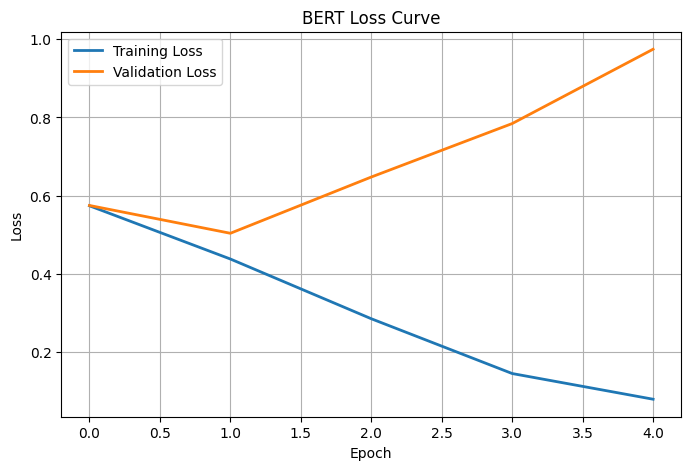

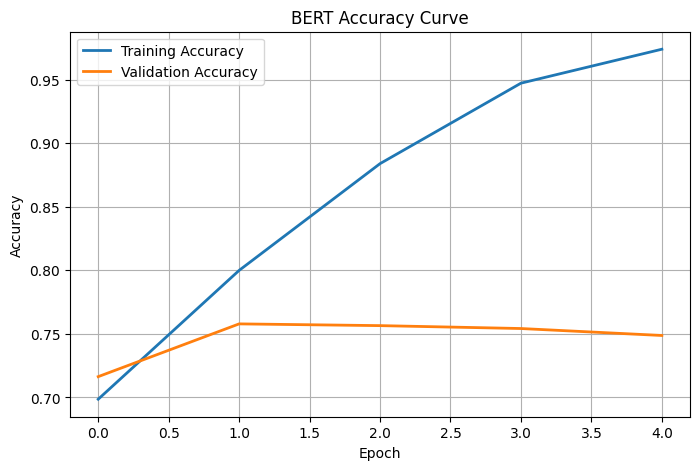

In [34]:
plot_loss(history_bert, "BERT")
plot_accuracy(history_bert, "BERT")

In [35]:
bert_results = evaluate_model( bert_model,test_loader,criterion,device)

Accuracy  : 0.7673
Precision : 0.7692
Recall    : 0.7673
F1 Score  : 0.7661


#Free Gpu Memory

In [36]:
import gc

del bert_model
del optimizer
torch.cuda.empty_cache()
gc.collect()
print("BERT model cleared from GPU memory.")

BERT model cleared from GPU memory.


# Bart Tokenizer

In [17]:
bart_tokenizer = BartTokenizer.from_pretrained("facebook/bart-base")

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

# Create Bart Dataset

In [18]:
train_dataset = TextDataset(  train_texts, train_labels, bart_tokenizer)
val_dataset = TextDataset( val_texts,val_labels,bart_tokenizer)
test_dataset = TextDataset(test_texts,test_labels,bart_tokenizer)

#

#Bart DataLoaders

In [19]:
train_loader = DataLoader(train_dataset,batch_size=64,shuffle=True,)
val_loader = DataLoader( val_dataset,batch_size=64,shuffle=False)
test_loader = DataLoader(test_dataset,batch_size=64,shuffle=False)

# Initialize Bart Model

In [22]:
bart_model = BartEncoderForSequenceClassification(num_classes=num_labels)
bart_model = bart_model.to(device)
print(bart_model)

BartEncoderForSequenceClassification(
  (encoder): BartEncoder(
    (embed_tokens): BartScaledWordEmbedding(50265, 768, padding_idx=1)
    (embed_positions): BartLearnedPositionalEmbedding(1026, 768)
    (layers): ModuleList(
      (0-5): 6 x BartEncoderLayer(
        (self_attn): BartAttention(
          (k_proj): Linear(in_features=768, out_features=768, bias=True)
          (v_proj): Linear(in_features=768, out_features=768, bias=True)
          (q_proj): Linear(in_features=768, out_features=768, bias=True)
          (out_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (self_attn_layer_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (activation_fn): GELUActivation()
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (fc2): Linear(in_features=3072, out_features=768, bias=True)
        (final_layer_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      )
    )
    (layernorm_embedding): LayerNorm(

In [23]:
optimizer = AdamW(bart_model.parameters(),lr=2e-5)
history_bart = train_model(model=bart_model,train_loader=train_loader,val_loader=val_loader,criterion=criterion,optimizer=optimizer,device=device, epochs=5,save_dir="bart_checkpoints")

Epoch 1/5 [Train]:   0%|          | 0/270 [00:00<?, ?it/s]

Epoch 1/5 [Validation]:   0%|          | 0/35 [00:00<?, ?it/s]

Epoch [ 1/5] | Train Loss: 0.6997 | Train Acc: 0.5700 | Val Loss: 0.6352 | Val Acc: 0.6357


Epoch 2/5 [Train]:   0%|          | 0/270 [00:00<?, ?it/s]

Epoch 2/5 [Validation]:   0%|          | 0/35 [00:00<?, ?it/s]

...

Epoch 4/5 [Validation]:   0%|          | 0/35 [00:00<?, ?it/s]

Epoch [ 4/5] | Train Loss: 0.4348 | Train Acc: 0.7999 | Val Loss: 0.6445 | Val Acc: 0.6694


Epoch 5/5 [Train]:   0%|          | 0/270 [00:00<?, ?it/s]

Epoch 5/5 [Validation]:   0%|          | 0/35 [00:00<?, ?it/s]

Epoch [ 5/5] | Train Loss: 0.3725 | Train Acc: 0.8328 | Val Loss: 0.6814 | Val Acc: 0.6949


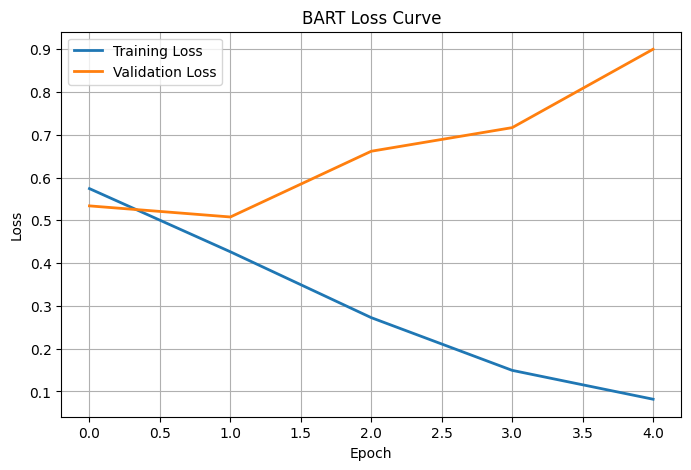

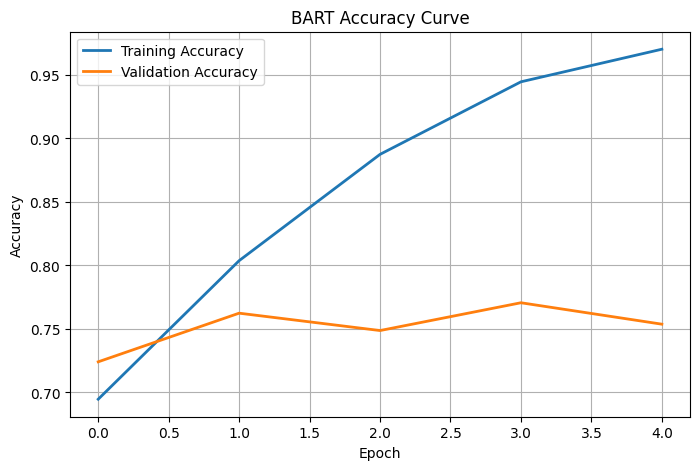

In [ ]:
plot_loss(history_bert, "BART")
plot_accuracy(history_bert, "BART")

In [ ]:
bart_results = evaluate_model( bart_model, test_loader, criterion, device)

Accuracy  : 0.6810
Precision : 0.6823
Recall    : 0.6810
F1 Score  : 0.6788
